IMPORTING THE LIBRARIES

In [32]:
import pandas as pd
import numpy as np
import seaborn as sns
import yfinance as yf
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import confusion_matrix,classification_report,f1_score
from sklearn.model_selection import RandomizedSearchCV

CREATING THE NEW FEATURES 

In [33]:
# 1. Prepare clean dataset
df_meta = yf.download("RELIANCE.NS", start="2011-01-01", end="2024-01-01")
if isinstance(df_meta.columns, pd.MultiIndex):
    df_meta.columns = [col[0] for col in df_meta.columns]

# 2. ADX Calculation
def get_adx(data, window=14):
    df = data.copy()
    df['up'] = df['High'].diff()
    df['down'] = -df['Low'].diff()
    df['+dm'] = np.where((df['up'] > df['down']) & (df['up'] > 0), df['up'], 0)
    df['-dm'] = np.where((df['down'] > df['up']) & (df['down'] > 0), df['down'], 0)
    df['tr'] = np.maximum(df['High'] - df['Low'], 
                          np.maximum(abs(df['High'] - df['Close'].shift(1)), 
                                     abs(df['Low'] - df['Close'].shift(1))))
    df['+di'] = 100 * (df['+dm'].rolling(window).mean() / df['tr'].rolling(window).mean())
    df['-di'] = 100 * (df['-dm'].rolling(window).mean() / df['tr'].rolling(window).mean())
    df['dx'] = 100 * abs(df['+di'] - df['-di']) / (df['+di'] + df['-di'])
    df['adx'] = df['dx'].rolling(window).mean()
    return df['adx']

df_meta['ADX'] = get_adx(df_meta)
ma20 = df_meta['Close'].rolling(20).mean()
std20 = df_meta['Close'].rolling(20).std()
df_meta['MA20'] = ma20
df_meta['BB_Width'] = (std20 * 4) / (ma20 + 1e-9)

# 3. Primary Signal & Meta Target
df_meta['Primary_Signal'] = 0
df_meta.loc[(df_meta['Close'] > ma20) & (df_meta['ADX'] > 20), 'Primary_Signal'] = 1

# Meta Target: Did the signal work?
df_meta['Return_5d'] = (df_meta['Close'].shift(-5) - df_meta['Close']) / df_meta['Close']
df_meta['Meta_Target'] = 0
df_meta.loc[(df_meta['Primary_Signal'] == 1) & (df_meta['Return_5d'] > 0), 'Meta_Target'] = 1

# 4. Momentum and extra features
df_meta['RSI'] = 100 - (100 / (1 + (df_meta['Close'].diff().where(df_meta['Close'].diff() > 0, 0).rolling(14).mean() / (abs(df_meta['Close'].diff().where(df_meta['Close'].diff() < 0, 0)).rolling(14).mean() + 1e-9))))
df_meta['ROC'] = df_meta['Close'].pct_change(10)

df_meta.dropna(inplace=True)

[*********************100%***********************]  1 of 1 completed


FEATURE SELECTION

In [34]:
#features = ['Open', 'High', 'Low', 'Volume'] 
features = ['ADX','BB_Width','RSI', 'ROC','Primary_Signal']

CREATING THE TRAINING AND TEST DATA 

In [35]:
train = df_meta[df_meta.index < '2021-01-01']
test = df_meta[df_meta.index >= '2021-01-01']
train = train.iloc[:-6]   # remove last 5 rows OF trains datas since it may provide data leakage of test data

X_train_m, y_train_m = train[features], train['Meta_Target']
X_test_m, y_test_m = test[features], test['Meta_Target']

STANDARD SCALING OF DATA

In [36]:
std=StandardScaler()
X_train_m=std.fit_transform(X_train_m)
X_test_m=std.transform(X_test_m)

DEFINING MY MODELS

In [37]:
models={
    'Random Forest': RandomForestClassifier(),
    "Adaboost":AdaBoostClassifier(),
    "Gradient Boost":GradientBoostingClassifier(),
    "Xgboost":XGBClassifier(),
}

RESULTS BEFORE HYPERPARAMETER TUNING

In [38]:
for i in range(len(list(models))):
    modell=list(models.values())[i]
    modell.fit(X_train_m,y_train_m)

    y_train_pred=modell.predict(X_train_m)
    y_test_pred=modell.predict(X_test_m)
    print("For Test Set: ")
    cm_test=confusion_matrix(y_test_m,y_test_pred)
    print(cm_test)
    print(classification_report(y_test_m,y_test_pred))
    print("***********************************************************************")

For Test Set: 
[[487  76]
 [ 85  88]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       563
           1       0.54      0.51      0.52       173

    accuracy                           0.78       736
   macro avg       0.69      0.69      0.69       736
weighted avg       0.78      0.78      0.78       736

***********************************************************************
For Test Set: 
[[411 152]
 [  0 173]]
              precision    recall  f1-score   support

           0       1.00      0.73      0.84       563
           1       0.53      1.00      0.69       173

    accuracy                           0.79       736
   macro avg       0.77      0.87      0.77       736
weighted avg       0.89      0.79      0.81       736

***********************************************************************
For Test Set: 
[[473  90]
 [ 77  96]]
              precision    recall  f1-score   support

           0       0.86      0.84

HYPER PARAMETER TUNING FOR OHCVL 

In [39]:
# params_rf= {
#     "max_depth": [5, 8, 15, None, 10],
#     "max_features": [5, 7, 8, 'sqrt', 'log2', None],
#     "min_samples_split": [2, 8, 15, 20],
#     "n_estimators": [100, 200, 500, 1000],
#     "criterion": ["gini", "entropy"],
#     "ccp_alpha": [0.0, 0.01, 0.1, 0.5, 1.0],
#     "max_leaf_nodes": [None,3,5,10, 20, 30, 50],
#     "bootstrap": [True, False],
#     "min_impurity_decrease": [0.0, 0.01, 0.1, 0.5, 1.0],
#     "random_state": [42,20],
#    "class_weight": [None, 'balanced', 'balanced_subsample']
# }

# adaboost_param={
#     random_state: [42, 20],
#     "n_estimators":[50,60,70,80,90],
#     "algorithm":['SAMME'],
#     "learning_rate":[0.01,0.05,0.1,0.5,1.0]
# }

# gradient_params={
#     "loss": ['log_loss','deviance','exponential'],
#     "criterion": ['friedman_mse','squared_error'],
#     "min_samples_split": [2, 8, 15, 20],
#     "n_estimators": [100, 200, 500],
#     "max_depth": [5, 8, 15, None, 10],
#     "learning_rate":[0.01,0.05,0.1,0.5,1.0],
#      "loss": ['log_loss','deviance','exponential'],
#     "learning_rate":[0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
#     "subsample": [0.6, 0.8, 1.0],
#     "max_features": ['sqrt', 'log2', None, 0.5, 0.8]
# }

# xgboost_params = {
#     "learning_rate": [0.01,0.05,0.1,0.5,1.0],
#     "max_depth": [4,5,6,7,8,9,10,11,12,13,14,15],
#     'reg_alpha':[1e-5, 1e-2, 0.1, 1, 100],
#     'reg_lambda':[1e-5, 1e-2, 0.1, 1, 100],
#     "n_estimators": [100, 200, 300],
#     "colsample_bytree": [0.5, 0.8, 1, 0.3, 0.4],
#     "objective": ['binary:logistic', 'binary:hinge', 'binary:logitraw'],
#     "eval_metric": ['logloss', 'error', 'auc'],
#     'scale_pos_weight': [1.2, 1.5, 2, 3],
#     'subsample': [0.6, 0.7, 0.8],
#     "objective": ['binary:logistic', 'binary:hinge', 'binary:logitraw'],
#     'min_child_weight': [1, 3, 5, 7],

# }

# randomcv_models = [
#                 ("RF", RandomForestClassifier(), params_rf),
#                 ("AdaBoost", AdaBoostClassifier(), adaboost_param),
#                 ("GradientBoost", GradientBoostingClassifier(), gradient_params),
#                 ("Xgboost", XGBClassifier(), xgboost_params)
#                 ]
# model_param = {}
# for name, model, params in randomcv_models:
#     random = RandomizedSearchCV(estimator=model,
#                                    param_distributions=params,
#                                    n_iter=200,
#                                    cv=3,
#                                    verbose=2,
#                                    n_jobs=-1)
#     random.fit(X_train_m, y_train_m)
#     model_param[name] = random.best_params_

# for model_name in model_param:
#     print(f"---------------- Best Params for {model_name} -------------------")
#     print(model_param[model_name])

DOING HYPER PARAMETER TUNING FOR NEW FEATURES 

In [40]:
# params_rf= {
#     "max_depth": [5, 8, 15, None, 10, 20],
#     "max_features": [5, 7, 8, 'sqrt', 'log2', None, 0.5, 0.8],
#     "min_samples_split": [2, 8, 15, 20, 30, 50],
#     "n_estimators": [100, 200, 500, 1000, 1500, 2000],
#     "criterion": ["gini", "entropy"],
#     "ccp_alpha": [0.0, 0.01, 0.1, 0.5, 1.0],
# }
# gradient_params={
#     "loss": ['log_loss','deviance','exponential'],
#     "criterion": ['friedman_mse','squared_error'],
#     "min_samples_split": [2, 8, 15, 20, 30, 50],
#     "n_estimators": [100, 200, 500, 1000, 1500, 2000],
#     "max_depth": [3, 5, 8, 10, 15, 20, None],
#     "learning_rate":[0.001, 0.01, 0.05, 0.1, 0.2, 0.3, 0.5],
#     "subsample": [0.6, 0.8, 1.0],
#     "max_features": ['sqrt', 'log2', None, 0.5, 0.8]
# }
# adaboost_param={
#     "n_estimators":[50,60,70,80,90],
#     "algorithm":['SAMME'],
#     "learning_rate":[0.01,0.05,0.1,0.5,1.0]
# }
# xgboost_params = {
#       'n_estimators': [500, 1000, 1500],
#     'max_depth': [3, 4, 5, 6],
#     'learning_rate': [0.005, 0.01, 0.02, 0.05],
#     'scale_pos_weight': [1.2, 1.5, 2, 3],
#     'subsample': [0.6, 0.7, 0.8],
#     'colsample_bytree': [0.6, 0.7, 0.8],
#     'gamma': [0, 0.1, 0.2],
#     'reg_alpha': [0, 0.1, 1],
#     'reg_lambda': [1, 5, 10],
#     'n_estimators': [500, 800, 1200, 1500],
#     'min_child_weight': [1, 3, 5, 7],
# }
# randomcv_models = [
#                 ("RF", RandomForestClassifier(), params_rf),
#                 ("AdaBoost", AdaBoostClassifier(), adaboost_param),
#                 ("GradientBoost", GradientBoostingClassifier(), gradient_params),
#                 ("Xgboost", XGBClassifier(), xgboost_params)
#                 ]
# model_param = {}
# for name, model, params in randomcv_models:
#     random = RandomizedSearchCV(estimator=model,
#                                    param_distributions=params,
#                                    n_iter=300,
#                                    cv=3,
#                                    verbose=2,
#                                    n_jobs=-1)
#     random.fit(X_train_m, y_train_m)
#     model_param[name] = random.best_params_

# for model_name in model_param:
#     print(f"---------------- Best Params for {model_name} -------------------")
#     print(model_param[model_name])

Tuned Model with OHCVL:

In [41]:
# models={
#     "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_split=15, max_features='log2', max_depth=8, criterion='entropy', ccp_alpha=0.1),
#     "AdaBoost":AdaBoostClassifier(n_estimators=50, learning_rate=0.01, algorithm='SAMME'),
#     "GradientBoostclassifier":GradientBoostingClassifier(n_estimators= 100, min_samples_split= 20, max_depth= 5, loss= 'exponential', learning_rate= 0.01, criterion= 'squared_error'),
#     "Xgboost":XGBClassifier(reg_lambda= 1e-05, reg_alpha= 100, objective= 'binary:logitraw', n_estimators= 100, max_depth= 7, learning_rate= 0.01, eval_metric= 'error', colsample_bytree= 0.5)
# }

Tunind Model with RSI , ADX , ROC,BB_WIDTH,PRIMARY SIGNAL

In [42]:
models={
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_split=20, max_features=8, max_depth=10, criterion='gini', ccp_alpha=0.1),
    "AdaBoost":AdaBoostClassifier(n_estimators=50, learning_rate=0.01, algorithm='SAMME'),
     "GradientBoostclassifier":GradientBoostingClassifier(subsample=1.0, n_estimators=500, min_samples_split=20, max_features=None, max_depth=8, loss='exponential', learning_rate=0.3, criterion='squared_error'),
     "Xgboost":XGBClassifier(subsample=0.6, scale_pos_weight=3, reg_lambda=1, reg_alpha=0, n_estimators=800, min_child_weight=5, max_depth=5, learning_rate=0.005, gamma=0, colsample_bytree=0.7)   
}

GETTING THE RESULT AFTER TUNING

In [43]:
model_predictions = {}

for i in range(len(list(models))):
    model_name = list(models.keys())[i]
    modell = list(models.values())[i]
    modell.fit(X_train_m, y_train_m)

    y_train_pred = modell.predict(X_train_m)
    y_test_pred = modell.predict(X_test_m)
    model_predictions[model_name] = y_test_pred # Store predictions for simulation

    print(F"For Test Set {model_name}: ")
    cm_test = confusion_matrix(y_test_m, y_test_pred)
    print(cm_test)
    print(classification_report(y_test_m, y_test_pred))
    print("***********************************************************************")

For Test Set Random Forest: 
[[411 152]
 [  0 173]]
              precision    recall  f1-score   support

           0       1.00      0.73      0.84       563
           1       0.53      1.00      0.69       173

    accuracy                           0.79       736
   macro avg       0.77      0.87      0.77       736
weighted avg       0.89      0.79      0.81       736

***********************************************************************
For Test Set AdaBoost: 
[[411 152]
 [  0 173]]
              precision    recall  f1-score   support

           0       1.00      0.73      0.84       563
           1       0.53      1.00      0.69       173

    accuracy                           0.79       736
   macro avg       0.77      0.87      0.77       736
weighted avg       0.89      0.79      0.81       736

***********************************************************************


d:\anaconda3\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:519: FutureWarning: The parameter 'algorithm' is deprecated in 1.6 and has no effect. It will be removed in version 1.8.
  warnings.warn(


For Test Set GradientBoostclassifier: 
[[489  74]
 [ 83  90]]
              precision    recall  f1-score   support

           0       0.85      0.87      0.86       563
           1       0.55      0.52      0.53       173

    accuracy                           0.79       736
   macro avg       0.70      0.69      0.70       736
weighted avg       0.78      0.79      0.78       736

***********************************************************************
For Test Set Xgboost: 
[[420 143]
 [  4 169]]
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       563
           1       0.54      0.98      0.70       173

    accuracy                           0.80       736
   macro avg       0.77      0.86      0.77       736
weighted avg       0.89      0.80      0.81       736

***********************************************************************


DOING MAJORITY VOTE TO GET THE RESULT OF THE MODEL

***********************************************************************
After Majority Voting on Test Set: 
f1 score(overall): 0.70
              precision    recall  f1-score   support

           0       0.99      0.75      0.85       563
           1       0.54      0.98      0.70       173

    accuracy                           0.80       736
   macro avg       0.77      0.86      0.77       736
weighted avg       0.89      0.80      0.81       736

***********************************************************************


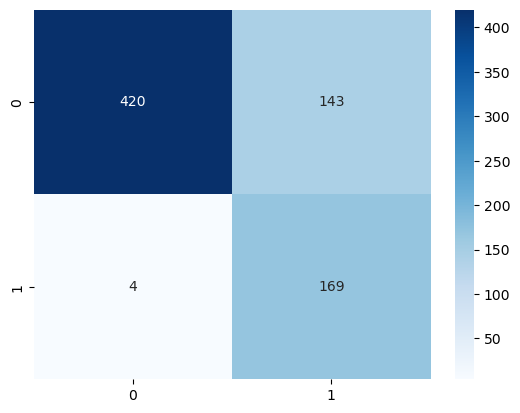

In [44]:
# Get predictions from each model
individual_predictions = []
for model_name, modell in models.items():
    individual_predictions.append(modell.predict(X_test_m))

individual_predictions = np.array(individual_predictions)

num_models = individual_predictions.shape[0]
majority_vote_predictions = (np.sum(individual_predictions, axis=0) > num_models / 2).astype(int)
print("***********************************************************************")
print(F"After Majority Voting on Test Set: ")
print(f"f1 score(overall): {f1_score(y_test_m, majority_vote_predictions):.2f}")
print(classification_report(y_test_m, majority_vote_predictions))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues')
print("***********************************************************************")


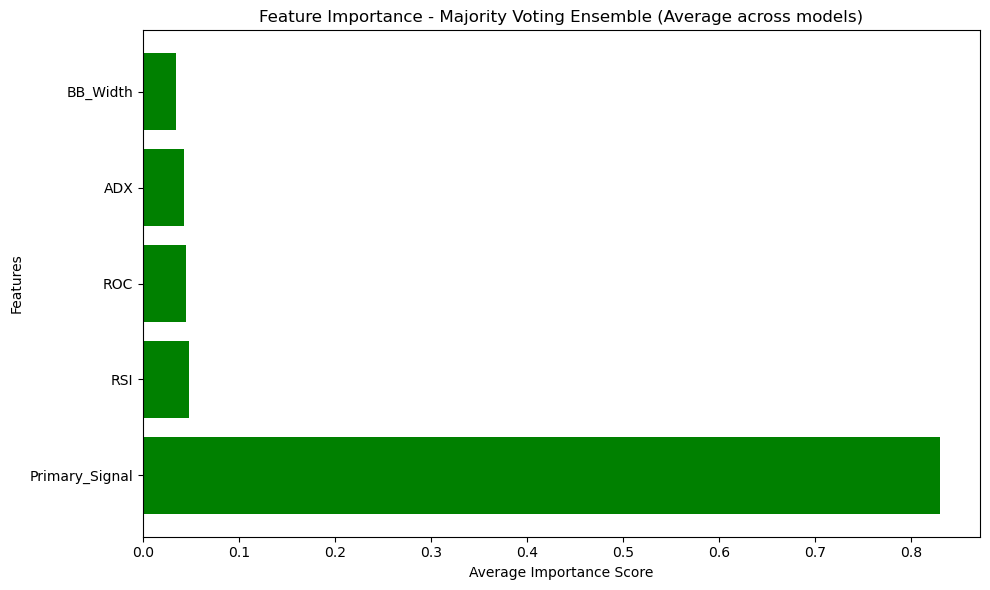

          Feature  Importance
4  Primary_Signal    0.830493
2             RSI    0.048168
3             ROC    0.044733
0             ADX    0.042620
1        BB_Width    0.033986


In [45]:
import matplotlib.pyplot as plt

feature_importances = []
for model_name, model in models.items():
    if hasattr(model, 'feature_importances_'):
        feature_importances.append(model.feature_importances_)
importance_avg = np.mean(feature_importances, axis=0)
importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance_avg
}).sort_values('Importance', ascending=False)
plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'], importance_df['Importance'], color='green')
plt.xlabel('Average Importance Score')
plt.ylabel('Features')
plt.title('Feature Importance - Majority Voting Ensemble (Average across models)')
plt.tight_layout()
plt.show()

print(importance_df)

HERE IS THE TRADING SIMULATION 

In [46]:
y_probs = majority_vote_predictions
initial_capital = 1000000  # Corrected: ₹1,000,000
capital = initial_capital
trade_logs = []
i = 0

while i < len(test) - 5: # Ensure we have enough days for T+5 exit
    # Get prices for T+1 (entry) and T+5 (exit)
    open_price = test['Open'].iloc[i+1]
    close_price = test['Close'].iloc[i+5]

    # Check if signal is valid and prices are available
    if pd.isna(open_price) or pd.isna(close_price):
        i += 1 # Move to next day if prices are missing
        continue

    if y_probs[i] == 1: # Go Long
        trade_return = (close_price / open_price) - 1 # Corrected Long Return calculation
        capital *= (1 + trade_return)
        trade_logs.append(trade_return)
        i += 5 # Advance by 5 days as per holding rule
    else: # Go Short
        trade_return = (open_price / close_price) - 1 # Short Return calculation is correct
        capital *= (1 + trade_return)
        trade_logs.append(trade_return)
        i += 5 # Corrected: Advance by 5 days as per holding rule for short trades too

print(f"Final Capital: ₹{capital:,.2f}")
print(f"Total Trades: {len(trade_logs)}")


# Calculate Sharpe Ratio
trade_logs=pd.DataFrame(trade_logs)
strategy_returns = trade_logs[0] 

# Define annualized risk-free rate
annual_rf = 0.05
daily_rf = annual_rf / 252

# Calculate excess returns
excess_returns = strategy_returns - daily_rf

# Calculate Annualized Sharpe Ratio
sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * np.sqrt(252)
#Caluculating the % retunrn
percentage_return = ((capital - initial_capital) / initial_capital) * 100
print(f"Overall Percentage Return: {percentage_return:.2f}%")
print(f"Win rate: {(trade_logs[0] > 0).mean() * 100:.2f}%")
print(f'Annualized Sharpe Ratio: {sharpe_ratio:.2f}')




Final Capital: ₹1,104,910.10
Total Trades: 147
Overall Percentage Return: 10.49%
Win rate: 53.74%
Annualized Sharpe Ratio: 0.49
